In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("Dataset .csv")

Data Exploration and Preprocesssing

In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
df.tail()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901
9550,5927402,Walter's Coffee Roastery,208,��stanbul,"Cafea��a Mahallesi, Bademalt۱ Sokak, No 21/B, ...",Moda,"Moda, ��stanbul",29.026016,40.984776,Cafe,...,Turkish Lira(TL),No,No,No,No,2,4.0,Green,Very Good,591


In [5]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 9551, Columns: 21


In [6]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [7]:
#droping row of missing values in cuisines
df=df.dropna(subset=['Cuisines'])

In [8]:
#converting 'Aggregate rating' to float
df['Agrregate rating']=df['Aggregate rating'].astype(float)

In [9]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

Text(0, 0.5, 'count')

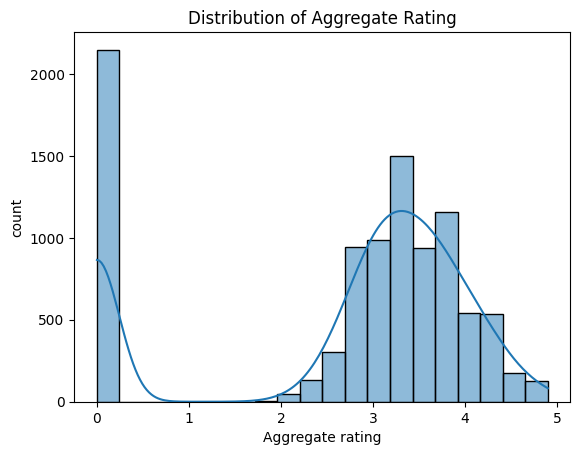

In [10]:
sns.histplot(df['Aggregate rating'],bins=20,kde=True)
plt.title("Distribution of Aggregate Rating")
plt.xlabel("Aggregate rating")
plt.ylabel("count")

Descriptive Analysis

In [11]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes,Agrregate rating
count,9.542000e+03,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000
mean,9.043301e+06,18.179208,64.274997,25.848532,1200.326137,1.804968,2.665238,156.772060,2.665238
std,8.791967e+06,56.451600,41.197602,11.010094,16128.743876,0.905563,1.516588,430.203324,1.516588
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000,0.000000
25%,3.019312e+05,1.000000,77.081565,28.478658,250.000000,1.000000,2.500000,5.000000,2.500000
50%,6.002726e+06,1.000000,77.192031,28.570444,400.000000,2.000000,3.200000,31.000000,3.200000
75%,1.835260e+07,1.000000,77.282043,28.642711,700.000000,2.000000,3.700000,130.000000,3.700000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000,4.900000


In [12]:
top_cuisines=df["Cuisines"].value_counts().head(10)
top_cuisines

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

In [13]:
top_cities=df["City"].value_counts().head(11)
top_cities

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Ahmedabad         21
Lucknow           21
Guwahati          21
Amritsar          21
S��o Paulo        20
Name: count, dtype: int64

In [14]:
#Restaurant count per country
country_counts=df["Country Code"].value_counts()
country_counts

Country Code
1      8652
216     425
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64

Geospatial Analysis

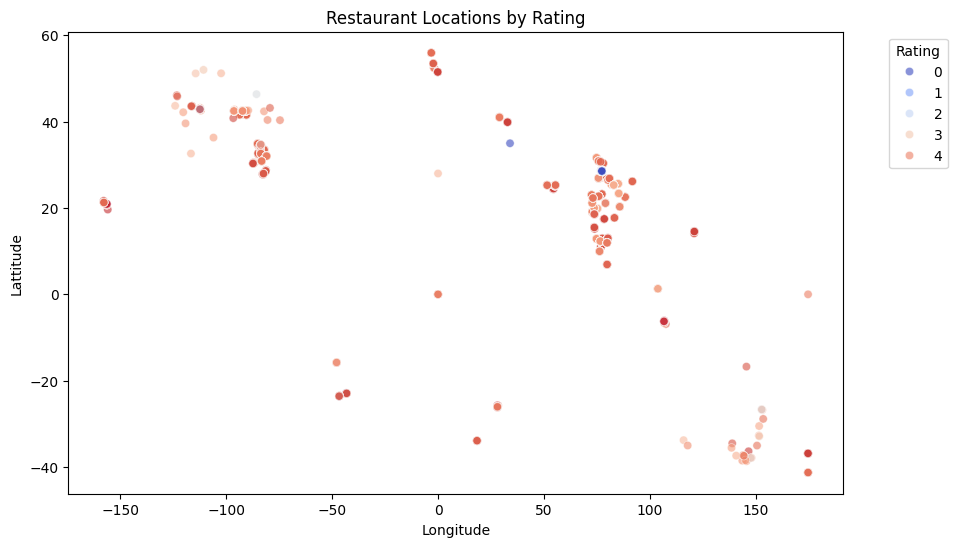

In [15]:
#restaurant location
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Longitude'],y=df['Latitude'],hue=df['Aggregate rating'],palette='coolwarm',alpha=0.6)
plt.title("Restaurant Locations by Rating")
plt.xlabel("Longitude")
plt.ylabel("Lattitude")
plt.legend(title="Rating",bbox_to_anchor=(1.05,1),loc='upper left')
plt.show()

In [16]:
#correlation between latitude and rating
correlation=df[['Latitude','Aggregate rating']].corr()
correlation


,Latitude,Aggregate rating
Latitude,1.000000,0.000197
Aggregate rating,0.000197,1.000000


In [17]:
#correlation between longitude and rating
correlation=df[['Longitude','Aggregate rating']].corr()
correlation


,Longitude,Aggregate rating
Longitude,1.000000,-0.114733
Aggregate rating,-0.114733,1.000000


Table Booking and Online Delivery

In [18]:
table_booking_percent=df['Has Table booking'].value_counts(normalize=True)*100
table_booking_percent                                                        

Has Table booking
No     87.864179
Yes    12.135821
Name: proportion, dtype: float64

In [19]:
online_delivery_percent=df['Has Online delivery'].value_counts(normalize=True)*100
online_delivery_percent

Has Online delivery
No     74.313561
Yes    25.686439
Name: proportion, dtype: float64

In [20]:
booking_rating=df.groupby('Has Table booking')['Aggregate rating'].mean()
booking_rating

Has Table booking
No     2.557956
Yes    3.441969
Name: Aggregate rating, dtype: float64

In [21]:
delivery_price = df.groupby(['Price range', 'Has Online delivery'])['Restaurant ID'].count().unstack().fillna(0)
delivery_price

Has Online delivery,No,Yes
Price range,,
1,3737,701
2,1827,1286
3,994,411
4,533,53


Price Range Analysis

In [22]:
most_common_price = df['Price range'].value_counts()
most_common_price

Price range
1    4438
2    3113
3    1405
4     586
Name: count, dtype: int64

In [23]:
price_rating_avg = df.groupby('Price range')['Aggregate rating'].mean()
price_rating_avg

Price range
1    1.997476
2    2.941054
3    3.682633
4    3.817918
Name: Aggregate rating, dtype: float64

In [24]:
rating_color_avg = df.groupby('Rating color')['Aggregate rating'].mean()
rating_color_avg

Rating color
Dark Green    4.659667
Green         4.167904
Orange        3.051339
Red           2.297849
White         0.000000
Yellow        3.683063
Name: Aggregate rating, dtype: float64

Feature Engineering

In [25]:
df['Name Length'] = df['Restaurant Name'].apply(len)
df['Address Length'] = df['Address'].apply(len)

In [26]:
df['Table Booking Binary'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Online Delivery Binary'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})

In [27]:
print("\nNewly Engineered Features:\n", df[['Name Length', 'Address Length', 'Table Booking Binary', 'Online Delivery Binary']].head())


Newly Engineered Features:
    Name Length  Address Length  Table Booking Binary  Online Delivery Binary
0           16              71                     1                       0
1           16              67                     1                       0
2           22              56                     1                       0
3            4              70                     0                       0
4           11              64                     1                       0


In [28]:
df['High Rating'] = df['Aggregate rating'].apply(lambda x: 1 if x >= 4.0 else 0)


Visualize key Insights

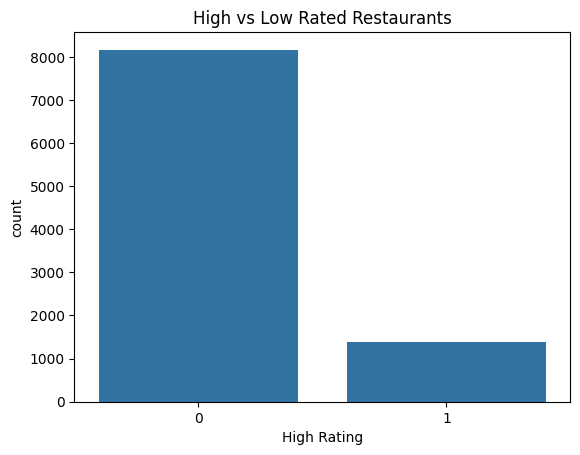

In [29]:
sns.countplot(data=df, x='High Rating') 
plt.title("High vs Low Rated Restaurants") 
plt.show()

C:\Users\gagan\AppData\Local\Temp\ipykernel_31104\2070112911.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Price range', palette='Set2')


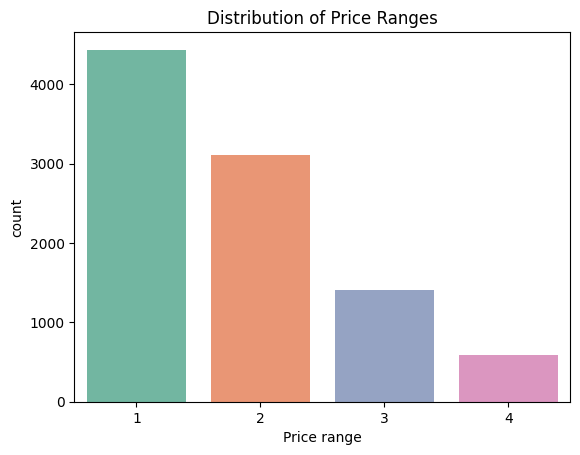

In [30]:
sns.countplot(data=df, x='Price range', palette='Set2') 
plt.title("Distribution of Price Ranges") 
plt.show()

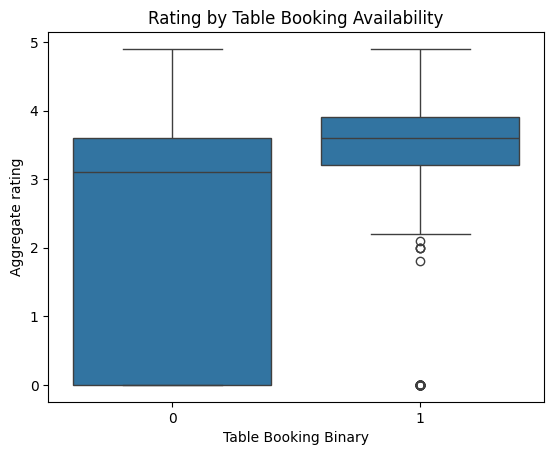

In [31]:
sns.boxplot(data=df, x='Table Booking Binary', y='Aggregate rating')
plt.title("Rating by Table Booking Availability") 
plt.show()

Correlation & Feature Importance

In [32]:
features = ['Price range', 'Name Length', 'Address Length', 'Table Booking Binary', 'Online Delivery Binary']
X = df[features] 
y = df['High Rating']

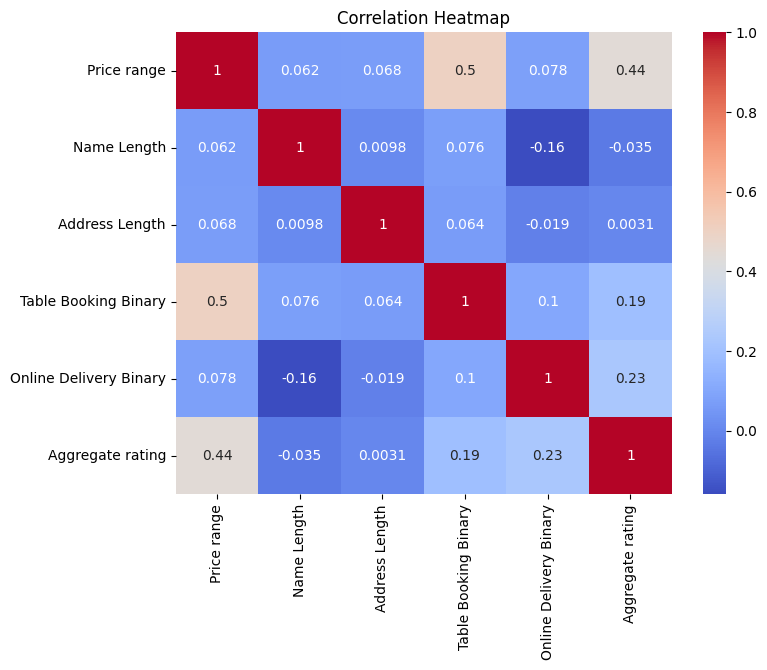

In [33]:
plt.figure(figsize=(8, 6)) 
sns.heatmap(df[features + ['Aggregate rating']].corr(), annot=True, cmap='coolwarm') 
plt.title("Correlation Heatmap") 
plt.show()


In [34]:
df_model = df[['Cuisines', 'Has Table booking', 'Has Online delivery',
               'Price range', 'Votes', 'Aggregate rating', 'Rating text']].dropna()

# Map categorical to binary
df_model['Has Table booking'] = df_model['Has Table booking'].map({'Yes': 1, 'No': 0})
df_model['Has Online delivery'] = df_model['Has Online delivery'].map({'Yes': 1, 'No': 0})
df_model['Votes'] = pd.to_numeric(df_model['Votes'], errors='coerce')
df_model = df_model.dropna()

In [35]:
df_model['Primary Cuisine'] = df_model['Cuisines'].apply(lambda x: x.split(',')[0].strip())

le_cuisine = LabelEncoder()
df_model['Cuisine Encoded'] = le_cuisine.fit_transform(df_model['Primary Cuisine'])

le_rating_text = LabelEncoder()
df_model['Rating Text Encoded'] = le_rating_text.fit_transform(df_model['Rating text'])

In [36]:
features = ['Has Table booking', 'Has Online delivery', 'Price range', 'Votes', 'Cuisine Encoded']
X = df_model[features]
y_reg = df_model['Aggregate rating']
y_clf = df_model['Rating Text Encoded']


In [37]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

In [38]:
reg_model = RandomForestRegressor(random_state=42)
reg_model.fit(X_train, y_reg_train)

RandomForestRegressor(random_state=42)

In [39]:
# Train classification model
clf_model = RandomForestClassifier(random_state=42)
clf_model.fit(X_train, y_clf_train)

RandomForestClassifier(random_state=42)

In [40]:
print("Regression MSE:", mean_squared_error(y_reg_test, reg_model.predict(X_test)))
print("Classification Accuracy:", accuracy_score(y_clf_test, clf_model.predict(X_test)))
print("\nClassification Report:\n", classification_report(
    y_clf_test, clf_model.predict(X_test), target_names=le_rating_text.classes_))

Regression MSE: 0.13076955568979248
Classification Accuracy: 0.6856993190151912

Classification Report:
               precision    recall  f1-score   support

     Average       0.75      0.79      0.77       753
   Excellent       0.21      0.14      0.17        57
        Good       0.45      0.44      0.44       418
   Not rated       1.00      1.00      1.00       431
        Poor       0.17      0.10      0.12        40
   Very Good       0.41      0.40      0.41       210

    accuracy                           0.69      1909
   macro avg       0.50      0.48      0.49      1909
weighted avg       0.67      0.69      0.68      1909



In [41]:
joblib.dump(reg_model, "restaurant_regressor.pkl")
joblib.dump(clf_model, "restaurant_classifier.pkl")

['restaurant_classifier.pkl']

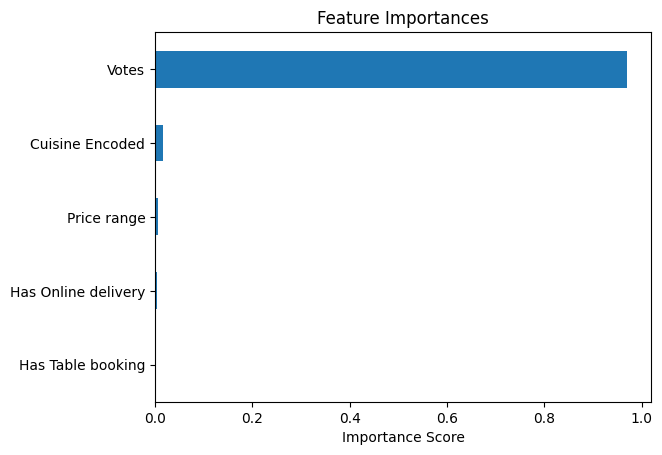

In [43]:
importances = pd.Series(reg_model.feature_importances_, index=features) 
importances.sort_values().plot(kind='barh', title="Feature Importances") 
plt.xlabel('Importance Score') 
plt.show()

Predictive Model & Evaluation

In [47]:
y_clf_pred = clf_model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_clf_test, y_clf_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.79      0.77       753
           1       0.21      0.14      0.17        57
           2       0.45      0.44      0.44       418
           3       1.00      1.00      1.00       431
           4       0.17      0.10      0.12        40
           5       0.41      0.40      0.41       210

    accuracy                           0.69      1909
   macro avg       0.50      0.48      0.49      1909
weighted avg       0.67      0.69      0.68      1909



In [48]:
y_reg_pred = reg_model.predict(X_test)
print("Regression Mean Squared Error:", mean_squared_error(y_reg_test, y_reg_pred))

Regression Mean Squared Error: 0.13076955568979248
